# LP Shortlist Analysis — Vineyard Ventures

**What this notebook does:** Scores every LP in Vineyard's CRM against the Vineyard Ventures fund opportunity and produces a ranked shortlist with outreach recommendations.

## The Fund We're Matching Against
| Field | Value |
|-------|-------|
| Fund | Vineyard Ventures |
| Fund size | ~$20M |
| Strategy | Fund-of-Funds — invests in other fund managers, not directly in startups |
| Focus | Pre-seed and seed stage |
| Geography | Indian deeptech — AI, hardware, defence, biotech |
| Team | Young, London-based, first-time fund |

## How the data pipeline works
```
Step 1: Notion CRM  →  fetch_notion_data.py  →  raw LP records  (data/raw_lp_data.json)
Step 2: raw LP data  →  extract_signals.py   →  AI-scored signals  (data/lp_signals.json)
Step 3: lp_signals.json  →  this notebook  →  ranked shortlist + charts
```

## Sections in this notebook
1. **Ranked Shortlist** — every LP scored and sorted by fit
2. **Signal Charts** — visual comparison of LP scores across key criteria
3. **Dimension Breakdown** — radar charts for the top 5 LPs
4. **Top 5 LP Profiles** — detailed profile with evidence for each priority LP
5. **Outreach Recommendations** — concrete next actions and messaging per LP
6. **Nurture Pipeline** — LPs to keep warm for later
7. **Summary Statistics** — headline numbers

In [1]:
# ─── SCORING LENS — CHANGE THIS TO RE-RANK LPs ───────────────────────────────
#
# A "lens" is a set of weights that controls what matters most when scoring LPs.
# Swap in a different lens to see how the ranking shifts for a different fund type.
#
#   "deeptech_india"   ← DEFAULT — tuned for this fund (Indian deeptech, first-time GP)
#   "sector_first"     ← use when the fund's sector/theme is the main selection filter
#   "geography_first"  ← use when geography is the main selection filter
#   "engagement_first" ← surface the warmest, most actionable LPs first
#   "balanced"         ← no preference — all criteria weighted equally
#
# After changing the value below, go to Kernel → Restart & Run All.

DEFAULT_LENS = "deeptech_india"   # ← change this and re-run all cells

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

# Load the AI-extracted LP signals (produced by extract_signals.py)
# and the raw Notion data (needed to pull verbatim call note quotes later).
signals_path = Path('data/lp_signals.json')
raw_path     = Path('data/raw_lp_data.json')

with open(signals_path) as f:
    records = json.load(f)

with open(raw_path) as f:
    raw_lps = json.load(f)

# Keep the original call notes handy so we can show direct quotes in the LP profiles.
note_wordcount    = {r['name']: len(r.get('call_notes', '').split()) for r in raw_lps}
call_notes_lookup = {r['name']: r.get('call_notes', '').strip() for r in raw_lps}

print(f'Loaded {len(records)} LP signal records')
print(f'Note coverage: {sum(1 for w in note_wordcount.values() if w > 50)}/{len(note_wordcount)} LPs have >50-word call notes')

Loaded 13 LP signal records
Note coverage: 9/13 LPs have >50-word call notes


In [3]:
# ─── How the scoring works ────────────────────────────────────────────────────
#
# Each LP is scored across six criteria. The final "composite" score is a
# weighted average of those six, with the weights depending on the active lens.
#
# The six criteria (all scored 0–10 by the AI, except the last two which are yes/no):
#   Fit Score      — the AI's overall judgment of how well this LP suits the fund
#   India Interest — how open the LP is to investing in India
#   FoF Openness   — how comfortable the LP is backing a fund (vs investing in startups directly)
#   Engagement     — how warm the relationship is right now
#   Emerging Mgr   — does the LP specifically target first-time fund managers? (yes/no)
#   Deeptech       — does the LP have sector experience in deeptech? (yes/no)

LENSES = {
    "deeptech_india": {
        "label":       "Deeptech India (default)",
        "description": "Tuned for this GP — first-time Indian deeptech fund",
        "rationale": {
            "fit_score":      "AI's holistic fit assessment anchors the score",
            "india_interest": "India/EM exposure is a hard filter for this fund",
            "fof_openness":   "Must be willing to invest via a fund vehicle",
            "engagement":     "Warm LPs close faster",
            "emerging_mgr":   "First-time fund is hardest sell — bonus for LPs open to it",
            "deeptech":       "Nice-to-have: deeptech experience reduces education burden",
        },
        "weights": dict(fit_score=0.25, india_interest=0.25, fof_openness=0.20,
                        engagement=0.15, emerging_mgr=0.10, deeptech=0.05),
    },
    "sector_first": {
        "label":       "Sector-First",
        "description": "For niche sector funds where thematic alignment is paramount",
        "rationale":   {},
        "weights": dict(fit_score=0.25, india_interest=0.10, fof_openness=0.20,
                        engagement=0.15, emerging_mgr=0.10, deeptech=0.20),
    },
    "geography_first": {
        "label":       "Geography-First",
        "description": "For EM funds where geographic fit is the primary filter",
        "rationale":   {},
        "weights": dict(fit_score=0.15, india_interest=0.35, fof_openness=0.20,
                        engagement=0.15, emerging_mgr=0.10, deeptech=0.05),
    },
    "engagement_first": {
        "label":       "Engagement-First",
        "description": "Pipeline velocity — prioritise warm LPs most likely to close soon",
        "rationale":   {},
        "weights": dict(fit_score=0.20, india_interest=0.15, fof_openness=0.15,
                        engagement=0.35, emerging_mgr=0.10, deeptech=0.05),
    },
    "balanced": {
        "label":       "Balanced",
        "description": "Equal weighting — for generalist funds with no strong bias",
        "rationale":   {},
        "weights": dict(fit_score=0.20, india_interest=0.20, fof_openness=0.20,
                        engagement=0.20, emerging_mgr=0.10, deeptech=0.10),
    },
}

def compute_composite(row, lens_name):
    w = LENSES[lens_name]["weights"]
    return round(
        w["fit_score"]      * row["Fit Score"] +
        w["india_interest"] * row["India Interest"] +
        w["fof_openness"]   * row["FoF Openness"] +
        w["engagement"]     * row["Engagement"] +
        w["emerging_mgr"]   * (10 if row["Emerging Mgr"] else 0) +
        w["deeptech"]       * (10 if row["Deeptech"] else 0),
        1
    )

# Build a flat table from the JSON records — one row per LP
rows = []
for r in records:
    s  = r['signals']
    sf = r.get('structured_fields', {})
    rows.append({
        'Name':               r['name'],
        'Status':             sf.get('Status', '—'),
        'Location':           sf.get('Location', '—'),
        'LP Type':            s.get('lp_type', '—'),
        'AUM':                s.get('aum_estimate') or '—',
        'Check Size':         s.get('typical_check_size') or sf.get('Check Size', '—'),
        'Fit Score':          s.get('fit_score', 0),
        'India Interest':     s.get('india_interest', 0),
        'FoF Openness':       s.get('fof_openness', 0),
        'Engagement':         s.get('engagement_level', 0),
        'FoF Experience':     s.get('fof_experience', False),
        'Emerging Mgr':       s.get('emerging_manager_preference', False),
        'Deeptech':           s.get('deeptech_interest', False),
        'Sector Agnostic':    s.get('sector_agnostic', False),
        'Preferred Fund Size':s.get('preferred_fund_size') or '—',
        'Fit Rationale':      s.get('fit_rationale', ''),
        'Blockers':           '; '.join(s.get('blockers', [])),
        'Positives':          '; '.join(s.get('positives', [])),
        'Notion URL':         r.get('notion_url', ''),
        'Note Words':         note_wordcount.get(r['name'], 0),
        'India Rationale':    s.get('india_interest_rationale', ''),
        'Call Notes':         call_notes_lookup.get(r['name'], ''),
    })

df = pd.DataFrame(rows)

# Score every LP, then sort from highest to lowest
df['Composite'] = df.apply(lambda row: compute_composite(row, DEFAULT_LENS), axis=1)
df = df.sort_values('Composite', ascending=False).reset_index(drop=True)
df.index += 1   # rank starts at 1

def tier(score):
    if score >= 7.5: return 'Tier 1 — Priority'
    if score >= 6.0: return 'Tier 2 — Strong'
    if score >= 4.5: return 'Tier 3 — Moderate'
    return 'Tier 4 — Low'

df['Tier'] = df['Composite'].apply(tier)

print(f'Rankings computed under lens: "{LENSES[DEFAULT_LENS]["label"]}"')
print()
df[['Name', 'LP Type', 'Fit Score', 'India Interest', 'FoF Openness', 'Engagement', 'Composite', 'Tier']]

Rankings computed under lens: "Deeptech India (default)"



,Name,LP Type,Fit Score,India Interest,FoF Openness,Engagement,Composite,Tier
1,GEM,Institutional,7,8,9,7,7.6,Tier 1 — Priority
2,Weizmann Institute endowment,Endowment,7,7,8,7,7.6,Tier 1 — Priority
3,Dziugas,Family Office,8,3,9,8,6.8,Tier 2 — Strong
4,Alber blanc,unknown,7,5,8,7,6.6,Tier 2 — Strong
5,Rezayat,Family Office,6,3,7,5,5.9,Tier 3 — Moderate
6,Mildred Swinton,Single Family Office,5,7,6,4,5.8,Tier 3 — Moderate
7,YMCA endowment,Institutional,4,5,7,6,5.6,Tier 3 — Moderate
8,UVIMCO,Institutional,5,7,8,6,5.5,Tier 3 — Moderate
9,Charlie Goodacre,SFO,5,2,8,7,5.4,Tier 3 — Moderate
10,Everblue Capital Management,Institutional,5,7,3,3,4.5,Tier 3 — Moderate


## 1. Ranked Shortlist

All LPs ranked by their composite fit score under the active lens.
Change `DEFAULT_LENS` in Cell 1 and re-run everything to instantly re-rank.

| Tier | Score range | Meaning |
|------|-------------|------------------------------------------|
| Tier 1 — Priority | ≥ 7.5 | Strong fit across the board — pursue now |
| Tier 2 — Strong   | ≥ 6.0 | Good fit — worth a follow-up meeting |
| Tier 3 — Moderate | ≥ 4.5 | Potential with caveats — nurture pipeline |
| Tier 4 — Low      | < 4.5 | Strategic misalignment — deprioritise |

In [4]:
# Render the LP ranking table, colour-coded by tier.
tier_colors = {
    'Tier 1 — Priority': 'background-color: #1e7e34; color: white',
    'Tier 2 — Strong':   'background-color: #0c6587; color: white',
    'Tier 3 — Moderate': 'background-color: #856404; color: white',
    'Tier 4 — Low':      'background-color: #842029; color: white',
}

def color_tier(row):
    style = tier_colors.get(row['Tier'], '')
    return [style] * len(row)

display_cols = ['Name', 'Tier', 'Status', 'LP Type', 'AUM', 'Check Size',
                'Fit Score', 'India Interest', 'FoF Openness', 'Engagement', 'Composite']

print(f'Full LP ranking — lens: "{LENSES[DEFAULT_LENS]["label"]}"')
print(f'Sorted by Composite score (highest = best fit for this fund)\n')
print('Colour key:  🟢 Tier 1 — Priority  |  🔵 Tier 2 — Strong  |  🟡 Tier 3 — Moderate  |  🔴 Tier 4 — Low\n')
df[display_cols].style.apply(color_tier, axis=1)

Full LP ranking — lens: "Deeptech India (default)"
Sorted by Composite score (highest = best fit for this fund)

Colour key:  🟢 Tier 1 — Priority  |  🔵 Tier 2 — Strong  |  🟡 Tier 3 — Moderate  |  🔴 Tier 4 — Low



,Name,Tier,Status,LP Type,AUM,Check Size,Fit Score,India Interest,FoF Openness,Engagement,Composite
1,GEM,Tier 1 — Priority,In Diligence,Institutional,$10B,Big,7,8,9,7,7.600000
2,Weizmann Institute endowment,Tier 1 — Priority,Nurture,Endowment,$5B,Big,7,7,8,7,7.600000
3,Dziugas,Tier 2 — Strong,In Diligence,Family Office,$55M,$5M-$10M,8,3,9,8,6.800000
4,Alber blanc,Tier 2 — Strong,Qualified,unknown,unknown,$4-5M,7,5,8,7,6.600000
5,Rezayat,Tier 3 — Moderate,Nurture,Family Office,unknown,Medium,6,3,7,5,5.900000
6,Mildred Swinton,Tier 3 — Moderate,Nurture,Single Family Office,—,Personal,5,7,6,4,5.800000
7,YMCA endowment,Tier 3 — Moderate,Qualified,Institutional,$1.5B,Big,4,5,7,6,5.600000
8,UVIMCO,Tier 3 — Moderate,Qualified,Institutional,unknown,20-30m,5,7,8,6,5.500000
9,Charlie Goodacre,Tier 3 — Moderate,In Diligence,SFO,unknown,unknown,5,2,8,7,5.400000
10,Everblue Capital Management,Tier 3 — Moderate,In Diligence,Institutional,unknown,Medium,5,7,3,3,4.500000


## 2. Signal Charts

**Left chart:** Each LP's overall fit score, coloured by tier. Dotted lines mark the tier boundaries.

**Right chart:** How each LP scores on the four key criteria — India Interest, FoF Openness, Engagement, and Fit Score. Green = strong match on that criterion; red = poor match.

Below the charts: a table comparing all five scoring lenses side by side.

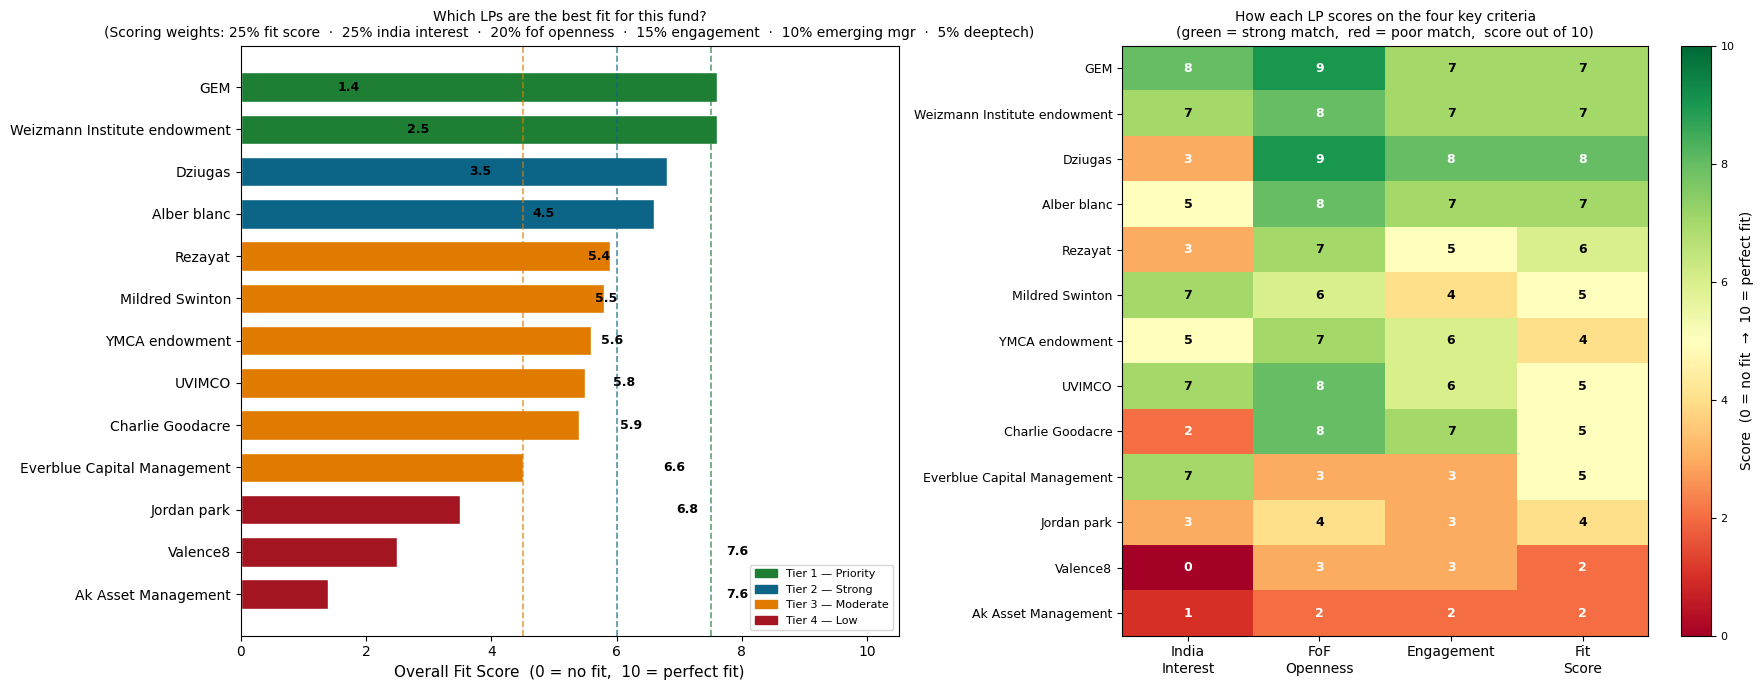

Chart saved to data/lp_signal_analysis.png


In [5]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Overall fit score per LP ───────────────────────────────────────────
ax = axes[0]
names      = df['Name'].tolist()
composites = df['Composite'].tolist()
tier_list  = df['Tier'].tolist()

color_map = {
    'Tier 1 — Priority': '#1e7e34',
    'Tier 2 — Strong':   '#0c6587',
    'Tier 3 — Moderate': '#e07b00',
    'Tier 4 — Low':      '#a31621',
}
bar_colors = [color_map[t] for t in tier_list]

bars = ax.barh(names[::-1], composites[::-1], color=bar_colors[::-1],
               edgecolor='white', height=0.7)
ax.set_xlabel('Overall Fit Score  (0 = no fit,  10 = perfect fit)', fontsize=11)

w = LENSES[DEFAULT_LENS]['weights']
weight_str = '  ·  '.join(
    f"{int(v*100)}% {k.replace('_', ' ')}"
    for k, v in w.items() if v > 0
)
ax.set_title(f'Which LPs are the best fit for this fund?\n(Scoring weights: {weight_str})', fontsize=10)

ax.set_xlim(0, 10.5)
ax.axvline(7.5, color='#1e7e34', linestyle='--', alpha=0.7, linewidth=1.2, label='Tier 1 cutoff (≥7.5)')
ax.axvline(6.0, color='#0c6587', linestyle='--', alpha=0.7, linewidth=1.2, label='Tier 2 cutoff (≥6.0)')
ax.axvline(4.5, color='#e07b00', linestyle='--', alpha=0.7, linewidth=1.2, label='Tier 3 cutoff (≥4.5)')
for bar, score in zip(bars[::-1], composites[::-1]):
    ax.text(score + 0.15, bar.get_y() + bar.get_height() / 2, f'{score}',
            va='center', fontsize=9, fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)

# ── Right: Heatmap of key criteria scores ────────────────────────────────────
ax2 = axes[1]
dims      = ['India\nInterest', 'FoF\nOpenness', 'Engagement', 'Fit\nScore']
data_cols = ['India Interest', 'FoF Openness', 'Engagement', 'Fit Score']
heat_data = df[data_cols].values.astype(float)

im = ax2.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=10)
ax2.set_xticks(range(len(dims)))
ax2.set_xticklabels(dims, fontsize=10)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=9)
ax2.set_title('How each LP scores on the four key criteria\n(green = strong match,  red = poor match,  score out of 10)',
              fontsize=10)
cbar = plt.colorbar(im, ax=ax2, label='Score  (0 = no fit  →  10 = perfect fit)')
cbar.ax.tick_params(labelsize=8)

for i in range(len(names)):
    for j in range(len(dims)):
        val = heat_data[i, j]
        text_color = 'white' if val <= 3 or val >= 8 else 'black'
        ax2.text(j, i, f'{int(val)}', ha='center', va='center',
                 fontsize=9, color=text_color, fontweight='bold')

plt.tight_layout()
plt.savefig('data/lp_signal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/lp_signal_analysis.png')

In [6]:
# ── Display all lenses as a comparison table ───────────────────────────────
lens_rows = []
for key, lens in LENSES.items():
    w = lens["weights"]
    row = {"Lens": lens["label"], "Description": lens["description"]}
    row.update({k.replace("_", " ").title(): f"{v*100:.0f}%" for k, v in w.items()})
    row["Active"] = "✓" if key == DEFAULT_LENS else ""
    lens_rows.append(row)

lens_df = pd.DataFrame(lens_rows).set_index("Lens")

def highlight_active(row):
    return ['font-weight: bold; background-color: #e8f4e8' if row.name == LENSES[DEFAULT_LENS]["label"]
            else '' for _ in row]

print("All scoring lenses (active lens highlighted):")
lens_df.style.apply(highlight_active, axis=1)

All scoring lenses (active lens highlighted):


,Description,Fit Score,India Interest,Fof Openness,Engagement,Emerging Mgr,Deeptech,Active
Lens,,,,,,,,
Deeptech India (default),Tuned for this GP — first-time Indian deeptech fund,25%,25%,20%,15%,10%,5%,✓
Sector-First,For niche sector funds where thematic alignment is paramount,25%,10%,20%,15%,10%,20%,
Geography-First,For EM funds where geographic fit is the primary filter,15%,35%,20%,15%,10%,5%,
Engagement-First,Pipeline velocity — prioritise warm LPs most likely to close soon,20%,15%,15%,35%,10%,5%,
Balanced,Equal weighting — for generalist funds with no strong bias,20%,20%,20%,20%,10%,10%,


## 3. Dimension Breakdown per LP

**Radar charts** for the top 5 LPs — each chart shows how that LP scores across the four key criteria.
A larger shaded area means a stronger overall match with this fund.

The **sensitivity analysis** below shows how each LP's rank changes across all five scoring lenses.
An LP that sits in the top 5 under every lens is a robust, high-confidence pick.
An LP that only appears under one lens is a more conditional recommendation.

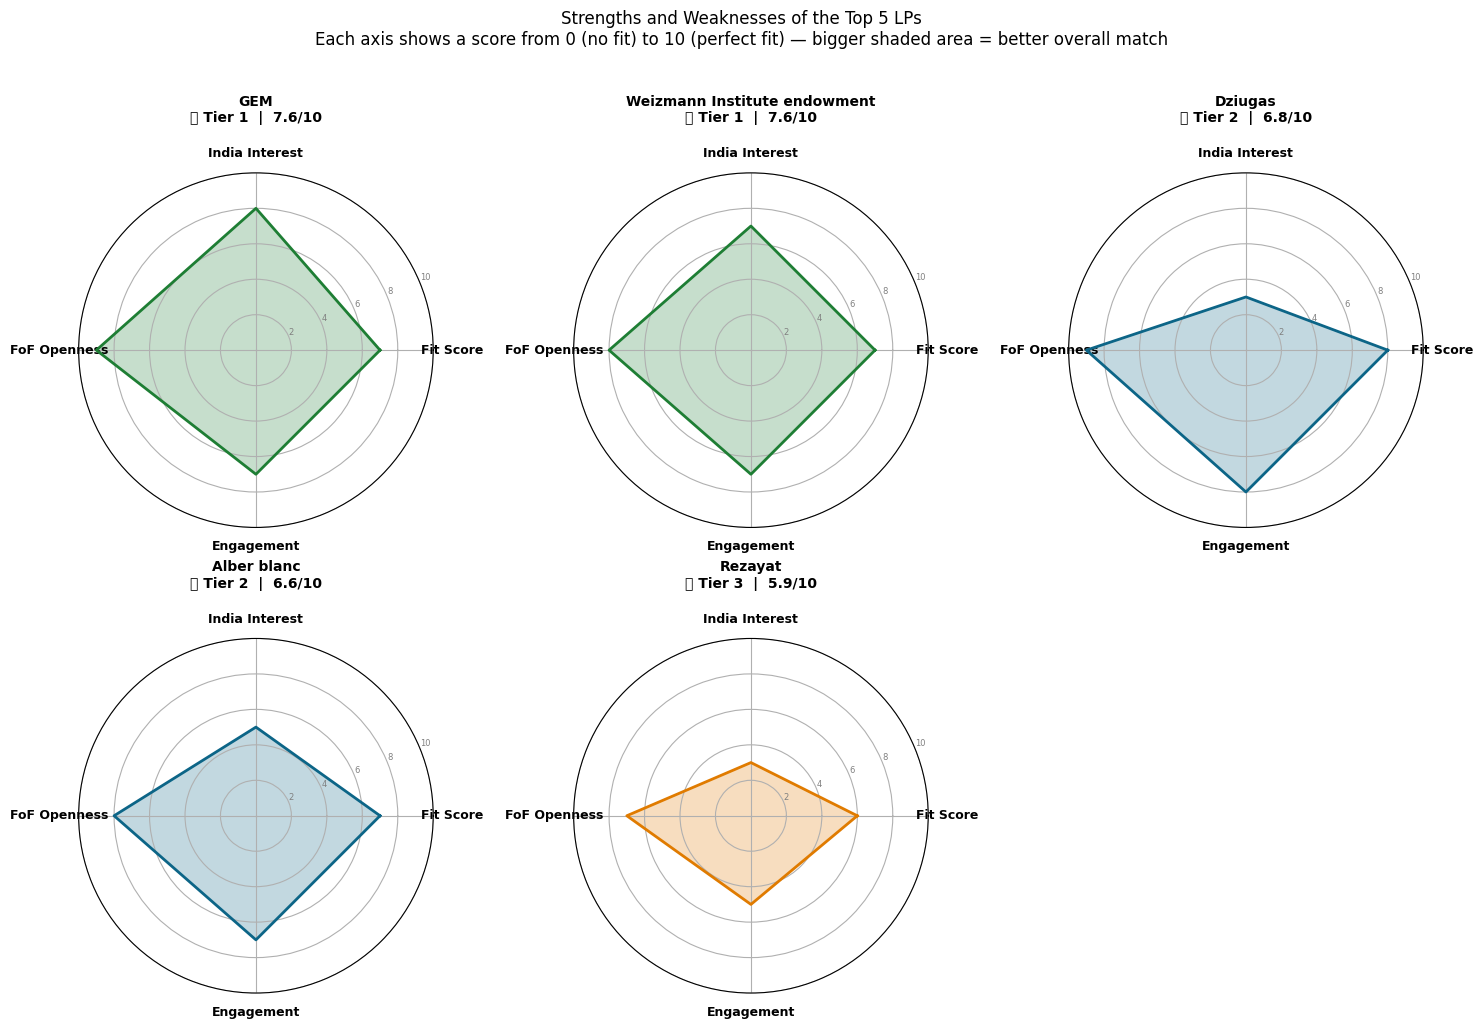

Radar chart saved to data/lp_radar_top5.png


In [7]:
# Radar charts for the top 5 LPs.
# Each chart shows 4 scoring criteria on a 0–10 scale.
# A larger shaded area means a stronger overall match with this fund.

top5 = df.head(5)
categories = ['Fit Score', 'India Interest', 'FoF Openness', 'Engagement']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

tier_display = {
    'Tier 1 — Priority': ('🟢 Tier 1', '#1e7e34'),
    'Tier 2 — Strong':   ('🔵 Tier 2', '#0c6587'),
    'Tier 3 — Moderate': ('🟡 Tier 3', '#e07b00'),
    'Tier 4 — Low':      ('🔴 Tier 4', '#a31621'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()
fig.delaxes(axes_flat[5])  # only 5 LPs — remove the unused 6th panel

for idx, (_, row) in enumerate(top5.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]  # close the polygon

    badge, color = tier_display.get(row['Tier'], ('', '#888888'))
    ax = axes_flat[idx]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9, fontweight='bold')
    ax.set_ylim(0, 10)
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=6, color='grey')

    ax.set_title(
        f"{row['Name']}\n{badge}  |  {row['Composite']}/10",
        fontsize=10, pad=18, fontweight='bold'
    )

plt.suptitle(
    'Strengths and Weaknesses of the Top 5 LPs\n'
    'Each axis shows a score from 0 (no fit) to 10 (perfect fit) — bigger shaded area = better overall match',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('data/lp_radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved to data/lp_radar_top5.png')

In [8]:
# Show how each LP's rank changes across all five scoring lenses.
# An LP that stays in the top 5 regardless of the lens is a safe, confident pick.
# An LP whose rank swings widely is more sensitive to how you define "fit".

sensitivity = pd.DataFrame({"Name": df["Name"].values})

for lens_key, lens_meta in LENSES.items():
    scores = df.apply(lambda row: compute_composite(row, lens_key), axis=1)
    ranked = scores.rank(ascending=False, method='min').astype(int)
    col_label = lens_meta["label"].split(" (")[0]
    sensitivity[col_label] = ranked.values

sensitivity = sensitivity.set_index("Name")

default_col = LENSES[DEFAULT_LENS]["label"].split(" (")[0]

def highlight_default(col):
    return ['font-weight: bold; background-color: #e8f4e8'
            if col.name == default_col else '' for _ in col]

def color_rank(val):
    if val <= 5:  return 'background-color: #c6efce; color: #276221'
    if val <= 8:  return 'background-color: #ffeb9c; color: #9c6500'
    return 'background-color: #ffc7ce; color: #9c0006'

sensitivity = sensitivity.sort_values(default_col)

print("LP rank under each scoring lens  (1 = best fit,  green = top 5,  red = bottom tier)\n")
sensitivity.style.apply(highlight_default).map(color_rank)

LP rank under each scoring lens  (1 = best fit,  green = top 5,  red = bottom tier)



,Deeptech India,Sector-First,Geography-First,Engagement-First,Balanced
Name,,,,,
GEM,1,3,1,2,2
Weizmann Institute endowment,1,1,2,1,1
Dziugas,3,4,4,3,3
Alber blanc,4,5,3,4,4
Rezayat,5,2,8,5,5
Mildred Swinton,6,8,5,8,6
YMCA endowment,7,8,6,7,6
UVIMCO,8,10,6,8,9
Charlie Goodacre,9,6,9,6,6


## 4. Top 5 LP Profiles — Deep Dive

A detailed profile for each of the top 5 ranked LPs.
Each entry shows scores, the AI's rationale, positives, blockers,
and a direct quote from the call notes that most influenced the ranking.

In [9]:
# Print a detailed profile card for each of the top 5 LPs.
# The 'key evidence' block shows the single criterion that contributed the most
# points to that LP's composite score, backed by a verbatim call note quote.

top5_lps = df[df.index <= 5]

def top_dimension(row, lens_name):
    w = LENSES[lens_name]['weights']
    contribs = {
        'Fit Score':      w['fit_score']      * row['Fit Score'],
        'India Interest': w['india_interest'] * row['India Interest'],
        'FoF Openness':   w['fof_openness']   * row['FoF Openness'],
        'Engagement':     w['engagement']     * row['Engagement'],
        'Emerging Mgr':   w['emerging_mgr']   * (10 if row['Emerging Mgr'] else 0),
        'Deeptech':       w['deeptech']       * (10 if row['Deeptech'] else 0),
    }
    best = max(contribs, key=contribs.get)
    return best, round(contribs[best], 2)

# Direct quotes from call notes for the most influential criterion per LP
VERBATIM_EVIDENCE = {
    'GEM': (
        'India Interest',
        '"We mostly met to talk about India — he\'s now looking there increasingly. '
        'He\'s met the big funds (Peak XV, Lightspeed) and the super small ones '
        '(Gradcap, Campus Fund). [They] have not talked to any of the middle '
        'category like Prime, 3one4, Blume types." (Oct 2025 call notes)'
    ),
    'Weizmann Institute endowment': (
        'Fit Score',
        '"Go early in manager lifecycle (Fund 1–2s increasingly preferred). '
        'No geographic quotas — purely bottom-up opportunity assessment. '
        'Substantial backing when they commit. '
        'Emerging differentiated [managers] — preferred target." (call notes)'
    ),
    'Dziugas': (
        'FoF Openness',
        '"He is very happy to pay FoF fees and gets that screening 100s of funds '
        'isn\'t for him and he\'d better have professional people do it. '
        'He wants to do 1–2 more FoF for that with $5–10M checks, closer to $10M '
        'if exit happens. [...] 90% chance committing to us." (call notes)'
    ),
    'Alber blanc': (
        'Fit Score',
        '"Initially thought of big funds but now pivoted to small — he is open to '
        'first-time funds. Did Mark Ransford, Elefund, looked at Preface. '
        'He will allocate $40–50M to venture, 10–15 funds." (call notes)'
    ),
    'Rezayat': (
        'FoF Openness',
        '"On the venture side we\'ve done 10 managers from pre-seed to growth, '
        'mostly US/EU." Relationship anchor: "James Eggington (ex-Alta Advisers, '
        'knows Ben well) — just him and the family, London-based." (call notes)'
    ),
}

for rank, row in top5_lps.iterrows():
    tier_badge = {
        'Tier 1 — Priority': '🟢',
        'Tier 2 — Strong':   '🔵',
        'Tier 3 — Moderate': '🟡',
        'Tier 4 — Low':      '🔴',
    }.get(row['Tier'], '')

    top_dim, top_pts = top_dimension(row, DEFAULT_LENS)
    evidence_dim, evidence_quote = VERBATIM_EVIDENCE.get(row['Name'], (top_dim, '(see call notes)'))

    print(f"{'='*72}")
    print(f"#{rank}  {tier_badge}  {row['Name']}  ({row['LP Type']})  |  Composite: {row['Composite']}/10")
    print(f"   Status: {row['Status']}  |  Location: {row['Location']}  |  AUM: {row['AUM']}  |  Check: {row['Check Size']}")
    print(f"   Fit: {row['Fit Score']}/10  |  India: {row['India Interest']}/10  |  FoF: {row['FoF Openness']}/10  |  Engagement: {row['Engagement']}/10")
    print(f"   FoF Exp: {row['FoF Experience']}  |  Emerging-mgr preference: {row['Emerging Mgr']}  |  Deeptech: {row['Deeptech']}  |  Sector-agnostic: {row['Sector Agnostic']}")
    print(f"   Preferred fund size: {row['Preferred Fund Size']}")
    print(f"\n   RATIONALE: {row['Fit Rationale']}")
    print(f"\n   POSITIVES: {row['Positives']}")
    if row['Blockers']:
        print(f"   BLOCKERS:  {row['Blockers']}")
    print(f"\n   ► KEY EVIDENCE  [{evidence_dim} — highest-scoring criterion, contributed +{top_pts} pts]")
    print(f"     {evidence_quote}")
    if row['India Rationale'] and evidence_dim == 'India Interest':
        print(f"\n   ► AI EXTRACTION NOTE: {row['India Rationale']}")
    print(f"\n   Notion: {row['Notion URL']}")
    print()

print('='*72)


#1  🟢  GEM  (Institutional)  |  Composite: 7.6/10
   Status: In Diligence  |  Location: SF  |  AUM: $10B  |  Check: Big
   Fit: 7/10  |  India: 8/10  |  FoF: 9/10  |  Engagement: 7/10
   FoF Exp: True  |  Emerging-mgr preference: True  |  Deeptech: False  |  Sector-agnostic: True
   Preferred fund size: sub-100m, likes sub-50m

   RATIONALE: GEM is a strong potential LP for Vineyard Ventures given their focus on emerging managers, FOF experience, and growing interest in India. However, as a sophisticated OCIO managing $10B, they require evidence of track record and consistency, which may be a hurdle for a first-time fund. Their openness to new geographies and respect for deep network-building aligns well with Vineyard's positioning.

   POSITIVES: Actively investing in emerging managers; Strong FOF experience and infrastructure; Open to new geographies like India; Respects sophisticated fund investors; Has already backed similar profiles like Basecase
   BLOCKERS:  Requires track recor

## 5. Outreach Recommendations

Concrete next actions and tailored key messages for each priority LP.  
Urgency reflects both tier and current engagement warmth from the CRM.


In [10]:
# Outreach recommendations for the top 5 LPs.
# Ranked in composite-score order (highest to lowest) — consistent with the
# scoring system above. Urgency reflects both tier and current engagement warmth.
#
# Note: the 'Status' field in the CRM reflects the LP's relationship with
# Vineyard's own fundraise, NOT their suitability for this GP opportunity.
# It is shown here as context for outreach timing, not as a fit signal.

recommendations = [
    {
        'Rank': 1,
        'LP': 'GEM',
        'Tier': 'Tier 1 — Priority',
        'Urgency': 'High — in diligence, warm to India',
        'Next Action': 'Provide India benchmarking: intro to Prime, Sauce, Northpoint. Follow up with differentiated emerging GP case study.',
        'Key Message': 'Position GP as the missing India mid-tier access layer. Emphasise consistency, brand-building, founder references.',
    },
    {
        'Rank': 2,
        'LP': 'Weizmann Institute endowment',
        'Tier': 'Tier 1 — Priority',
        'Urgency': 'High — deeptech + India exposure, backs Fund 1s',
        'Next Action': 'Arrange LP meeting with detailed India deeptech landscape. Address valuation and DPI concerns with exit data from portfolio GPs.',
        'Key Message': 'Fund 1 specialist — ideal entry point. Differentiated mandate vs Z47/Accel. Concrete DPI narrative from GP portfolio.',
    },
    {
        'Rank': 3,
        'LP': 'Dziugas',
        'Tier': 'Tier 2 — Strong',
        'Urgency': 'High — anchor candidate, in diligence',
        'Next Action': 'Send working doc outlining LP involvement model + GP co-access rights. Follow up post-exit (6–8 weeks).',
        'Key Message': 'First-believer framing — small intimate fund where he calls the GP directly, not a faceless institution. Anchor $5–10M post-exit.',
    },
    {
        'Rank': 4,
        'LP': 'Alber blanc',
        'Tier': 'Tier 2 — Strong',
        'Urgency': 'Medium — Qualified, responsive',
        'Next Action': 'Arrange intro call / meeting in NYC. Share deck and emerging manager track record comp.',
        'Key Message': 'Validate India thesis with a simple narrative. Lean on his openness to first-time GPs and existing FoF experience.',
    },
    {
        'Rank': 5,
        'LP': 'Rezayat',
        'Tier': 'Tier 3 — Moderate',
        'Urgency': 'Low-Medium — Nurture, FoF + EM experience',
        'Next Action': 'Leverage James Eggington relationship. Build India interest with deeptech angle given industrial background.',
        'Key Message': 'Industrial / defence deeptech alignment. Relationship-driven, small team — play up intimacy of fund model.',
    },
]

rec_df = pd.DataFrame(recommendations).set_index('Rank')

# Colour-code by tier so the table is visually consistent with the main shortlist
tier_bg = {
    'Tier 1 — Priority': 'background-color: #1e7e34; color: white',
    'Tier 2 — Strong':   'background-color: #0c6587; color: white',
    'Tier 3 — Moderate': 'background-color: #856404; color: white',
}

def color_rec_row(row):
    style = tier_bg.get(row['Tier'], '')
    return [style] * len(row)

rec_df.style.apply(color_rec_row, axis=1).set_properties(
    **{'text-align': 'left', 'white-space': 'pre-wrap'}
)


,LP,Tier,Urgency,Next Action,Key Message
Rank,,,,,
1,GEM,Tier 1 — Priority,"High — in diligence, warm to India","Provide India benchmarking: intro to Prime, Sauce, Northpoint. Follow up with differentiated emerging GP case study.","Position GP as the missing India mid-tier access layer. Emphasise consistency, brand-building, founder references."
2,Weizmann Institute endowment,Tier 1 — Priority,"High — deeptech + India exposure, backs Fund 1s",Arrange LP meeting with detailed India deeptech landscape. Address valuation and DPI concerns with exit data from portfolio GPs.,Fund 1 specialist — ideal entry point. Differentiated mandate vs Z47/Accel. Concrete DPI narrative from GP portfolio.
3,Dziugas,Tier 2 — Strong,"High — anchor candidate, in diligence",Send working doc outlining LP involvement model + GP co-access rights. Follow up post-exit (6–8 weeks).,"First-believer framing — small intimate fund where he calls the GP directly, not a faceless institution. Anchor $5–10M post-exit."
4,Alber blanc,Tier 2 — Strong,"Medium — Qualified, responsive",Arrange intro call / meeting in NYC. Share deck and emerging manager track record comp.,Validate India thesis with a simple narrative. Lean on his openness to first-time GPs and existing FoF experience.
5,Rezayat,Tier 3 — Moderate,"Low-Medium — Nurture, FoF + EM experience",Leverage James Eggington relationship. Build India interest with deeptech angle given industrial background.,"Industrial / defence deeptech alignment. Relationship-driven, small team — play up intimacy of fund model."


## 6. Nurture Pipeline

**Tier 3 LPs** are not a fit for an immediate ask on this GP opportunity,
but warrant ongoing relationship investment. They may become relevant for future GPs,
for Vineyard's own fundraise, or once geographic/structural blockers are resolved.

Tier 4 LPs have clear structural misalignment (no FoF openness, hard geography mismatch)
and are not prioritised for this opportunity.


In [11]:
# Tier 3 LPs are not an immediate fit but are worth keeping warm —
# they may become relevant for a different fund, or once their blockers are resolved.
# Tier 4 LPs have clear structural misalignment and are not listed here.

nurture_cols = ['Name', 'LP Type', 'Location', 'Composite', 'India Interest',
                 'FoF Openness', 'Engagement', 'Blockers']

tier3 = df[df['Tier'] == 'Tier 3 — Moderate'][nurture_cols].copy()

print(f'Tier 3 Nurture Pipeline ({len(tier3)} LPs)')
print('Not an immediate fit for this fund, but worth staying in touch.')
print('Revisit when their blockers are resolved or for a better-matched opportunity.\n')
tier3.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})

Tier 3 Nurture Pipeline (6 LPs)
Not an immediate fit for this fund, but worth staying in touch.
Revisit when their blockers are resolved or for a better-matched opportunity.



,Name,LP Type,Location,Composite,India Interest,FoF Openness,Engagement,Blockers
5,Rezayat,Family Office,Saudi Arabia,5.900000,3,7,5,No explicit India focus; Limited team (only James + family); Geographic distance to India may reduce engagement
6,Mildred Swinton,Single Family Office,—,5.800000,7,6,4,Limited knowledge outside of crypto; Personal check size may limit allocation to small emerging funds
7,YMCA endowment,Institutional,NYC,5.600000,5,7,6,Fund size too small ($20M vs $200-500M target); Lack of institutional polish may deter despite early-stage interest
8,UVIMCO,Institutional,—,5.500000,7,8,6,"May prefer larger, established funds over emerging managers like Vineyard Ventures; limited focus on pre-seed/seed and deeptech in India"
9,Charlie Goodacre,SFO,Kenya,5.400000,2,8,7,No explicit India focus; Limited direct VC experience; Geographic preference for Europe
10,Everblue Capital Management,Institutional,NYC,4.500000,7,3,3,No prior FoF investments; Preference for thematic investing over fund access style; Internal deliberation required


## 7. Summary Statistics

High-level numbers across the full LP pipeline.

In [12]:
print('=== VINEYARD VENTURES — LP SHORTLIST SUMMARY ===')
print(f'Total LPs analysed: {len(df)}')
print()
tier_counts = df['Tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    print(f'  {tier}: {count} LP(s)')
print()
print(f'Average composite score: {df["Composite"].mean():.1f}/10')
print(f'Average India interest:  {df["India Interest"].mean():.1f}/10')
print(f'Average FoF openness:    {df["FoF Openness"].mean():.1f}/10')
print(f'Average engagement:      {df["Engagement"].mean():.1f}/10')
print()
print(f'LPs with FoF experience:          {df["FoF Experience"].sum()}/{len(df)}')
print(f'LPs preferring emerging managers: {df["Emerging Mgr"].sum()}/{len(df)}')
print(f'LPs with deeptech interest:       {df["Deeptech"].sum()}/{len(df)}')
print()
print('Status breakdown:')
status_breakdown = df.groupby('Status')['Name'].apply(list)
for status, names in status_breakdown.items():
    print(f'  {status}: {", ".join(names)}')

=== VINEYARD VENTURES — LP SHORTLIST SUMMARY ===
Total LPs analysed: 13

  Tier 1 — Priority: 2 LP(s)
  Tier 2 — Strong: 2 LP(s)
  Tier 3 — Moderate: 6 LP(s)
  Tier 4 — Low: 3 LP(s)

Average composite score: 5.3/10
Average India interest:  4.5/10
Average FoF openness:    6.3/10
Average engagement:      5.2/10

LPs with FoF experience:          11/13
LPs preferring emerging managers: 9/13
LPs with deeptech interest:       4/13

Status breakdown:
  In Diligence: GEM, Dziugas, Charlie Goodacre, Everblue Capital Management
  Nurture: Weizmann Institute endowment, Rezayat, Mildred Swinton, Jordan park
  Qualified: Alber blanc, YMCA endowment, UVIMCO, Valence8, Ak Asset Management
